# ใบงานที่ 2 Data Preprocessing

## LAB1 : Dataset Exploration 


### **1) Load Dataset**
    Load the Spotify 2023 dataset from Kaggle into a Pandas DataFrame using latin1 encoding to handle special characters.

ref : https://www.kaggle.com/code/adhamtarek147/most-streamed-spotify-songs-2023


In [70]:
import pandas as pd

df = pd.read_csv('spotify-2023.csv', encoding='latin1')

### **2) Display Shape (row,column)**
    Check the dimensions of the dataset to determine the total number of rows (tracks) and columns (features).

In [71]:
print("Shape:", df.shape)

Shape: (953, 24)


### **3) Display Data Types**
    Inspect the data types of each column to identify numerical and categorical features, as well as potential data type misclassifications.

In [72]:
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Info ---")
print(df.info())


--- Data Types ---
track_name                str
artist(s)_name            str
artist_count            int64
released_year           int64
released_month          int64
released_day            int64
in_spotify_playlists    int64
in_spotify_charts       int64
streams                   str
in_apple_playlists      int64
in_apple_charts         int64
in_deezer_playlists       str
in_deezer_charts        int64
in_shazam_charts          str
bpm                     int64
key                       str
mode                      str
danceability_%          int64
valence_%               int64
energy_%                int64
acousticness_%          int64
instrumentalness_%      int64
liveness_%              int64
speechiness_%           int64
dtype: object

--- Info ---
<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   track_name            953 non-null 

### **4) Display Summary Statistics**
    Generate descriptive statistics for numerical and categorical columns to understand the distribution, central tendencies, and variability of the data.

In [73]:
print("\n--- Summary Statistics ---")
print(df.describe()) # Numeric columns only
print("\n--- All Columns ---")
print(df.describe(include='all'))


--- Summary Statistics ---
       artist_count  released_year  released_month  released_day  \
count        953.00         953.00          953.00        953.00   
mean           1.56        2018.24            6.03         13.93   
std            0.89          11.12            3.57          9.20   
min            1.00        1930.00            1.00          1.00   
25%            1.00        2020.00            3.00          6.00   
50%            1.00        2022.00            6.00         13.00   
75%            2.00        2022.00            9.00         22.00   
max            8.00        2023.00           12.00         31.00   

       in_spotify_playlists  in_spotify_charts  in_apple_playlists  \
count                953.00             953.00              953.00   
mean                5200.12              12.01               67.81   
std                 7897.61              19.58               86.44   
min                   31.00               0.00                0.00   
25%      

### **5) Display Missing Values**
    Identify missing or null values across all columns to evaluate data completeness before preprocessing.

In [74]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
track_name               0
artist(s)_name           0
artist_count             0
released_year            0
released_month           0
released_day             0
in_spotify_playlists     0
in_spotify_charts        0
streams                  0
in_apple_playlists       0
in_apple_charts          0
in_deezer_playlists      0
in_deezer_charts         0
in_shazam_charts        50
bpm                      0
key                     95
mode                     0
danceability_%           0
valence_%                0
energy_%                 0
acousticness_%           0
instrumentalness_%       0
liveness_%               0
speechiness_%            0
dtype: int64


### **6) Display Duplicate Records**
    Check for duplicate rows in the dataset to ensure data integrity and avoid redundant entries.

In [75]:
print("\n--- Duplicate Records ---")
print("Total duplicates:", df.duplicated().sum())
print("\n--- Duplicate Rows ---")
print(df[df.duplicated()])
print("\n--- Duplicate track names ---")
print(df.duplicated(subset=['track_name']).sum())
print("\n--- Duplicate artist names ---")
print(df.duplicated(subset=['artist(s)_name']).sum())


--- Duplicate Records ---
Total duplicates: 0

--- Duplicate Rows ---
Empty DataFrame
Columns: [track_name, artist(s)_name, artist_count, released_year, released_month, released_day, in_spotify_playlists, in_spotify_charts, streams, in_apple_playlists, in_apple_charts, in_deezer_playlists, in_deezer_charts, in_shazam_charts, bpm, key, mode, danceability_%, valence_%, energy_%, acousticness_%, instrumentalness_%, liveness_%, speechiness_%]
Index: []

[0 rows x 24 columns]

--- Duplicate track names ---
10

--- Duplicate artist names ---
308


### **7) Display Class Distribution**
    Analyze the frequency distribution of categorical variables, such as musical key and mode, to understand their overall proportions in the dataset.

In [76]:
print("--- Mode Distribution ---")
print(df['mode'].value_counts())

print("\n--- Key Distribution ---")
print(df['key'].value_counts())

--- Mode Distribution ---
mode
Major    550
Minor    403
Name: count, dtype: int64

--- Key Distribution ---
key
C#    120
G      96
G#     91
F      89
B      81
D      81
A      75
F#     73
E      62
A#     57
D#     33
Name: count, dtype: int64


## LAB2 : Data Visualization 


### **1) Histogram**
    Plot histograms to visualize the data distribution and density of continuous numerical variables (e.g., BPM or Audio Features).
*(Note: If you encounter a ModuleNotFoundError: No module named 'matplotlib', run pip install matplotlib seaborn to install the required packages.)*

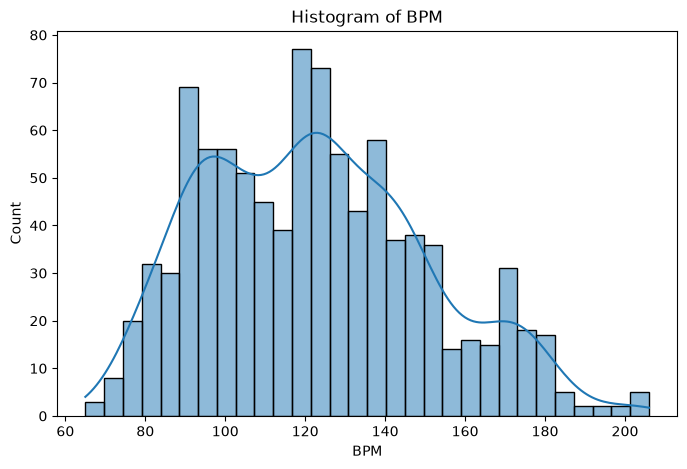

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['bpm'], kde=True, bins=30)
plt.title('Histogram of BPM')
plt.xlabel('BPM')
plt.ylabel('Count')
plt.show()

### **2) Correlation Heatmap**
    Display a correlation heatmap to identify linear relationships and associations between numerical features.

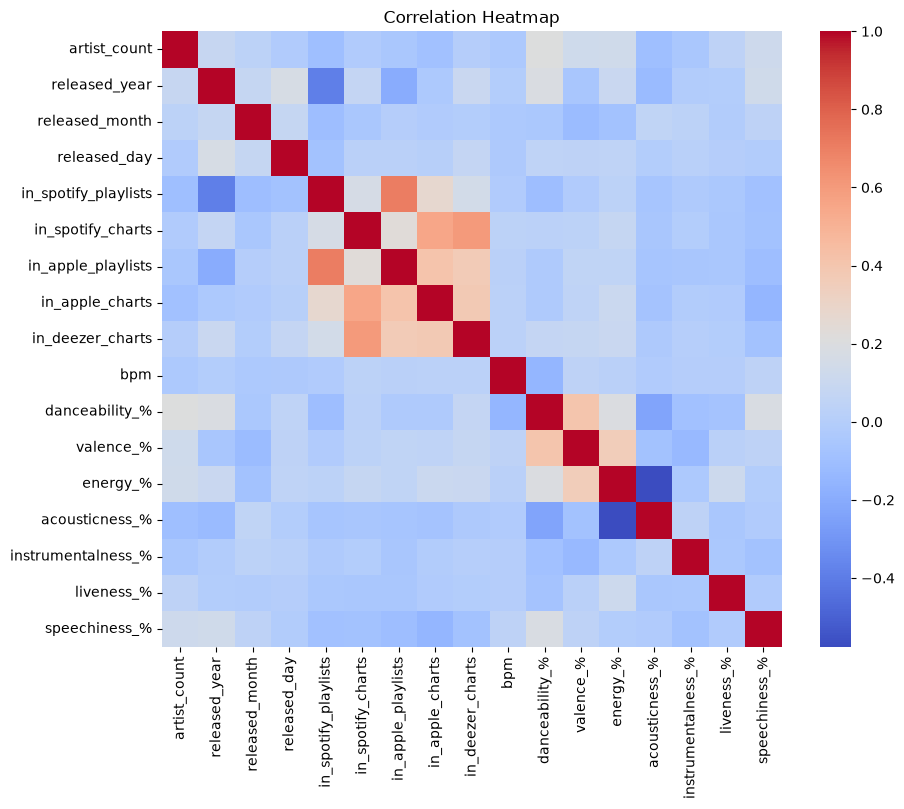

In [78]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Part 3 : Data Cleaning


### **1) Missing Value Handling**
    Handle missing values by imputing missing numerical features with their median and replacing missing categorical values with `'Unknown'`.

In [79]:
import pandas as pd
import numpy as np

df_clean = df.copy() #Create a copy of the original DataFrame to clean

In [80]:
# Fill missing categorical values in 'key'
if 'key' in df_clean.columns:
    df_clean['key'] = df_clean['key'].fillna('Unknown')

# Fill missing numeric values with Median
num_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

print("--- Missing Values After Handling ---")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0]) # ควรจะขึ้น Empty Series (ไม่มีค่าว่างเหลือแล้ว)

--- Missing Values After Handling ---
in_shazam_charts    50
dtype: int64


### **2) Duplicate Removal**
    Identify and remove duplicate rows to ensure data uniqueness across the dataset.

In [81]:
# Check and remove duplicate rows
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
removed_duplicates = initial_rows - len(df_clean)

print(f"Total duplicates removed: {removed_duplicates}")

Total duplicates removed: 0


### **3) Incorrect Data Correction**
    Clean non-numeric characters (such as commas `,` or erroneous strings) from numeric columns before conversion.

In [82]:
# Clean commas and non-numeric noise from string columns that should be numbers
cols_to_clean = ['streams', 'in_deezer_playlists', 'in_shazam_charts']

for col in cols_to_clean:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.replace(',', '', regex=False).str.strip()

### **4) Data Type Conversion**
    Convert data types of relevant columns (e.g., `streams`, `in_deezer_playlists`, `in_shazam_charts`) to proper numerical formats (`float64` or `int64`).

In [83]:
# Convert corrected string columns into numeric types
for col in cols_to_clean:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

print("--- Updated Data Types ---")
print(df_clean[cols_to_clean].dtypes)

--- Updated Data Types ---
streams                float64
in_deezer_playlists      int64
in_shazam_charts       float64
dtype: object


### **Compare: Mean & Median**
**5) Mean**
    
    Calculate the arithmetic mean for each numerical feature to measure the central tendency.
**6) Median**
    
    Calculate the median (50th percentile) for each numerical feature to assess the central value that is robust to outliers.

In [84]:
# Select only numeric columns for mean and median calculations
numeric_df = df_clean.select_dtypes(include=[np.number])

# 5. Mean Calculation
mean_values = numeric_df.mean()

# 6. Median Calculation
median_values = numeric_df.median()

# Comparison of Mean and Median
compare_df = pd.DataFrame({
    'Mean (ข้อ 5)': mean_values,
    'Median (ข้อ 6)': median_values,
    'Difference (Mean - Median)': mean_values - median_values
})

# Set display format for better readability
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("--- Comparison: Mean vs Median ---")
print(compare_df)

--- Comparison: Mean vs Median ---
                      Mean (ข้อ 5)  Median (ข้อ 6)  Difference (Mean - Median)
artist_count                  1.56            1.00                        0.56
released_year              2018.24         2022.00                       -3.76
released_month                6.03            6.00                        0.03
released_day                 13.93           13.00                        0.93
in_spotify_playlists       5200.12         2224.00                     2976.12
in_spotify_charts            12.01            3.00                        9.01
streams               514137424.94    290530915.00                223606509.94
in_apple_playlists           67.81           34.00                       33.81
in_apple_charts              51.91           38.00                       13.91
in_deezer_playlists         385.19           44.00                      341.19
in_deezer_charts              2.67            0.00                        2.67
in_shazam_charts 

## Part 4 : Feature Engineering

### **1) Label Encoding**
    Encode categorical features with ordinal or binary relationship into integer values (e.g., converting `mode` into binary values `0` and `1`).
*(Note : if you encounter a ModuleNotFoundError: No module named 'sklearn', run pip install scikit-learn to install the required packages.)*

In [85]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Create a copy of the cleaned DataFrame for feature engineering
df_fe = df_clean.copy()

In [86]:
# Apply Label Encoding to 'mode' (Major / Minor)
le = LabelEncoder()

if 'mode' in df_fe.columns:
    df_fe['mode_encoded'] = le.fit_transform(df_fe['mode'])
    
    print("--- 1. Label Encoding Result ('mode') ---")
    print(df_fe[['mode', 'mode_encoded']].head())

--- 1. Label Encoding Result ('mode') ---
    mode  mode_encoded
0  Major             0
1  Major             0
2  Major             0
3  Major             0
4  Minor             1


### **2) One-Hot Encoding**
    Convert categorical variables without implicit ordering into binary indicator variables (e.g., converting `key` into separate binary 0/1 columns).

In [87]:
# Apply One-Hot Encoding to 'key' (C, C#, D, E, etc.)
if 'key' in df_fe.columns:
    df_fe = pd.get_dummies(df_fe, columns=['key'], prefix='key', dtype=int)
    
    print("\n--- 2. One-Hot Encoding Result ('key') ---")
    key_cols = [col for col in df_fe.columns if col.startswith('key_')]
    print(df_fe[key_cols].head())


--- 2. One-Hot Encoding Result ('key') ---
   key_A  key_A#  key_B  key_C#  key_D  key_D#  key_E  key_F  key_F#  key_G  \
0      0       0      1       0      0       0      0      0       0      0   
1      0       0      0       1      0       0      0      0       0      0   
2      0       0      0       0      0       0      0      1       0      0   
3      1       0      0       0      0       0      0      0       0      0   
4      1       0      0       0      0       0      0      0       0      0   

   key_G#  key_Unknown  
0       0            0  
1       0            0  
2       0            0  
3       0            0  
4       0            0  
